In [4]:
# Instalar Ultralytics (YOLOv8)
!pip install ultralytics --upgrade

In [5]:
# Instalar Rasterio
!pip install rasterio

In [6]:
# Instalar Pytorch
!pip install torchvision

In [7]:
# ============================================================
# Libs a serem importadas
# ============================================================

from IPython.display import Image, display
import rasterio
from rasterio.windows import Window
import os
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
import shutil
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import numpy as np
from ultralytics import YOLO
from torchvision.ops import nms
from PIL import Image

In [8]:
# Verificar instalação do yolov8 (opcional)
!yolo checks



Ultralytics 8.3.233  Python-3.9.13 torch-2.6.0+cpu CPU (Intel Core i3-10110U 2.10GHz)
Setup complete  (4 CPUs, 3.9 GB RAM, 107.0/118.4 GB disk)

OS                     Windows-10-10.0.22631-SP0
Environment            Windows
Python                 3.9.13
Install                pip
Path                   C:\Users\alice\anaconda3\Lib\site-packages\ultralytics
RAM                    3.86 GB
Disk                   107.0/118.4 GB
CPU                    Intel Core i3-10110U 2.10GHz
CPU count              4
GPU                    None
GPU count              None
CUDA                   None

numpy                   1.24.4>=1.23.0
matplotlib              3.5.2>=3.3.0
opencv-python           4.10.0.84>=4.6.0
pillow                  11.0.0>=7.1.2
pyyaml                  6.0>=5.3.1
requests                2.28.1>=2.23.0
scipy                   1.9.1>=1.4.1
torch                   2.6.0>=1.8.0
torch                   2.6.0!=2.4.0,>=1.8.0; sys_platform == "win32"
torchvision             0.21.0>=0.

In [9]:
caminho = "C:/Users/alice/Downloads/Codigo final"

In [10]:
# ============================================================
# divisão imagem em tiles
# ============================================================

# Caminhos de entrada e saída (altere de acordo com seu caminho)
tif_path = caminho + "/campus.tif"
tile_output = caminho + "/tiles"
os.makedirs(tile_output, exist_ok=True)

# Definição dos parâmetros de corte
tile_size = 1024 # Tamanho de cada tile (em pixels), gerando recortes de 1024x1024
overlap = 0.4 # Percentual de sobreposição entre tiles (40%)
stride = int(tile_size * (1 - overlap)) # Passo de deslocamento (quanto anda na imagem antes de gerar o próximo tile)
tile_coords = [] # Lista para armazenar nome do tile e suas coordenadas

# Abre a imagem GeoTIFF com rasterio
with rasterio.open(tif_path) as src:
    width, height = src.width, src.height # Obtém largura e altura totais da imagem
    tile_id = 0                           # Contador de tiles gerados
    # Loop para percorrer a imagem verticalmente (topo → baixo)
    for top in range(0, height - tile_size + 1, stride):
      # Loop para percorrer a imagem horizontalmente (esquerda → direita)
        for left in range(0, width - tile_size + 1, stride):
            window = Window(left, top, tile_size, tile_size) # Define uma janela (recorte) da imagem no ponto (left, top)
            img = src.read(window=window) # Lê os pixels correspondentes a essa janela
            img = img.transpose(1, 2, 0) # Transpõe o array (bandas, linhas, colunas → linhas, colunas, bandas)
            img = Image.fromarray(img) # Converte o array em uma imagem PIL
            # Define o nome do tile e salva como PNG
            tile_name = f"tile_{tile_id}.png"
            img.save(os.path.join(tile_output, tile_name))
            tile_coords.append((tile_name, left, top)) # Guarda o nome e as coordenadas do tile
            tile_id += 1 # Incrementa o contador

# num total de tiles gerados.
print(f"Total de tiles gerados: {tile_id}")

Total de tiles gerados: 135


In [11]:
# ============================================================
# EXTRAÇÃO DAS ANOTAÇÕES DE ÁRVORES A PARTIR DO ARQUIVO XML
# ============================================================

# Caminho do arquivo XML que contém as anotações das árvores
xml_path = caminho + "/campus.xml"

# Carrega e analisa o XML
tree = ET.parse(xml_path)
root = tree.getroot()

# Coletar todas as anotações
objects = [] # Lista onde serão armazenadas as anotações (bounding boxes)

# Percorre todos os objetos anotados no XML
for obj in root.findall("object"):
    label = obj.find("name").text.lower()
    # Filtra apenas as classes de interesse ("arvore" ou "tree")
    if label in ["arvore", "tree"]:
        box = obj.find("bndbox")
        # Extrai as coordenadas da caixa delimitadora
        xmin = int(float(box.find("xmin").text))
        ymin = int(float(box.find("ymin").text))
        xmax = int(float(box.find("xmax").text))
        ymax = int(float(box.find("ymax").text))
        # Adiciona a anotação na lista
        objects.append((xmin, ymin, xmax, ymax))

In [12]:
# ============================================================
# Preparação do dataset: criação das pastas, separação em
# treino/validação e geração dos labels no formato YOLO
# ============================================================

# Cria a estrutura de diretórios padrão do YOLO
# (imagens e labels divididos em train e val)
base_dir = caminho + "/dataset"
for sub in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(os.path.join(base_dir, sub), exist_ok=True)

# Divide os tiles em treino (80%) e validação (20%)
# random_state garante que a divisão seja sempre a mesma
train_tiles, val_tiles = train_test_split(tile_coords, test_size=0.2, random_state=42)

# Função para processar os tiles de cada divisão (train ou val)
def process_tiles(tile_list, split):
    for tile_name, x0, y0 in tile_list:
        tile_path = os.path.join(tile_output, tile_name) # Caminho do tile original
        img_dest = os.path.join(base_dir, f"images/{split}", tile_name) # Caminho de destino da imagem (train ou val)
        lbl_dest = os.path.join(base_dir, f"labels/{split}", tile_name.replace(".png", ".txt")) # Caminho de destino do label correspondente (em .txt)
        shutil.copy(tile_path, img_dest) # Copia a imagem tile para a pasta correta

        # Lista para armazenar as bounding boxes (no formato YOLO)
        bboxes = []
        for xmin, ymin, xmax, ymax in objects:
          # Verifica se a bounding box está completamente dentro do tile
            if xmin >= x0 and xmax <= x0 + tile_size and ymin >= y0 and ymax <= y0 + tile_size:
                # Converte as coordenadas absolutas (pixels) para normalizadas (0-1)
                # Formato YOLO: class x_center y_center width height
                x_center = ((xmin + xmax) / 2 - x0) / tile_size
                y_center = ((ymin + ymax) / 2 - y0) / tile_size
                width = (xmax - xmin) / tile_size
                height = (ymax - ymin) / tile_size
                bboxes.append(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}") # Classe 0 = árvore

        # Se houver bounding boxes no tile, salva o arquivo .txt correspondente
        if bboxes:
            with open(lbl_dest, "w") as f:
                f.write("\n".join(bboxes))

# Processa e salva os tiles de treino e validação
process_tiles(train_tiles, "train")
process_tiles(val_tiles, "val")

In [13]:
# ============================================================
# Remoção de tiles sem anotações (tiles "vazios")
# ============================================================

def remove_empty_tiles(image_dir, label_dir):
    count = 0 # Contador de quantos tiles foram removidos
    # Percorre todos os arquivos dentro do diretório de imagens
    for filename in os.listdir(image_dir):
        # Garante que só serão processados arquivos de imagem .png
        if not filename.endswith(".png"):
            continue

        # Nome correspondente do arquivo de label (.txt)
        base_name = filename.replace(".png", ".txt")
        label_path = os.path.join(label_dir, base_name)
        image_path = os.path.join(image_dir, filename)

        # Se não existir arquivo de label OU se o arquivo estiver vazio:
        if not os.path.exists(label_path) or os.stat(label_path).st_size == 0:
            os.remove(image_path) # Remove a imagem
            if os.path.exists(label_path): # Remove o label vazio (se existir)
                os.remove(label_path)
            count += 1 # Atualiza o contador

    print(f"{count} tiles sem anotações foram removidos de {image_dir}.")

# ============================================================
# Aplicando a limpeza nos conjuntos de treino e validação
# ============================================================

remove_empty_tiles(
    (base_dir + "/images/train"),
    (base_dir + "/labels/train")
)

remove_empty_tiles(
    (base_dir + "/images/val"),
    (base_dir + "/labels/val")
)

# ============================================================
# Contagem final de tiles com árvores após a limpeza
# ============================================================

print("Tiles com árvore (treino):", len(glob((base_dir + "/labels/train/*.txt"))))
print("Tiles com árvore (validação):", len(glob((base_dir + "/labels/val/*.txt"))))

52 tiles sem anotações foram removidos de C:/Users/alice/Downloads/Codigo final/dataset/images/train.
11 tiles sem anotações foram removidos de C:/Users/alice/Downloads/Codigo final/dataset/images/val.
Tiles com árvore (treino): 56
Tiles com árvore (validação): 16


In [14]:
# ============================================================
# Função para plotar as bounding boxes YOLO em uma imagem
# ============================================================

def plot_yolo_boxes(image_path, label_path, class_names=["Tree"]):
    # Abrir imagem
    image = Image.open(image_path)
    width, height = image.size

    # Verifica se existe arquivo de labels
    if not os.path.exists(label_path):
        print("Nenhum arquivo de label encontrado.")
        return

    # Lê as anotações do arquivo .txt (formato YOLO)
    with open(label_path, "r") as f:
        lines = f.readlines()

    # Cria a figura para exibição da imagem
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image) # Mostra a imagem como fundo

    # Percorre cada linha (bounding box) do arquivo de labels
    for line in lines:
        cls_id, x_center, y_center, w, h = map(float, line.strip().split())
        # Converte valores normalizados para coordenadas em pixels
        x_center *= width
        y_center *= height
        w *= width
        h *= height
        xmin = x_center - w / 2
        ymin = y_center - h / 2

        # Desenha o retângulo da bounding box
        rect = patches.Rectangle(
            (xmin, ymin), w, h,
            linewidth=2, edgecolor="red", facecolor="none"
        )
        ax.add_patch(rect)
        # Adiciona o nome da classe acima da bounding box
        ax.text(xmin, ymin - 5, class_names[int(cls_id)], color="white", fontsize=12,
                bbox=dict(facecolor="red", alpha=0.5))

    # Remove eixos e adiciona título
    plt.axis("off")
    plt.title(f"Caixas da imagem: {os.path.basename(image_path)}")
    plt.show()

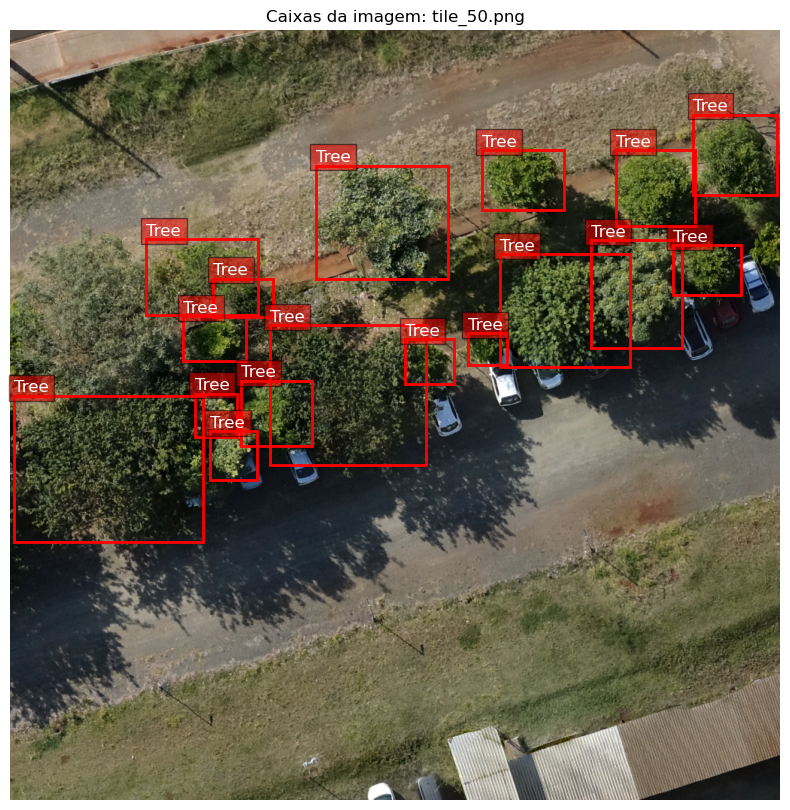

In [15]:
# ============================================================
# Exemplo de visualização de um tile de treino com suas labels
# ============================================================

image_file = base_dir + "/images/train/tile_50.png"
label_file = base_dir + "/labels/train/tile_50.txt"

plot_yolo_boxes(image_file, label_file, class_names=["Tree"])

In [16]:
# ============================================================
# Criação do arquivo de configuração YAML para o YOLO
# ============================================================

# Conteúdo do arquivo YAML
yaml_content = """
path: C:/Users/alice/Downloads/Codigo final/dataset # Caminho base do dataset
train: images/train                                              # Subpasta com imagens de treino
val: images/val                                                  # Subpasta com imagens de validação
names:                                                           # Definição das classes
  0: Tree                                                        # Classe 0 = árvore
"""

# Cria (ou sobrescreve) o arquivo data.yaml no diretório do dataset
with open((base_dir + "/data.yaml"), "w") as f:
    f.write(yaml_content)

In [17]:
# ============================================================
# Treinamento do modelo YOLOv8
# ============================================================

model = YOLO("yolov8s.yaml")  #yolov8s.yaml para melhor precisão

# Iniciar o treinamento
model.train(
    # Caminho para o arquivo data.yaml (define dataset e classes)
    data=base_dir + "/data.yaml",
    epochs=100, # Número de épocas (ciclos completos sobre o dataset)
    imgsz=1024, # Tamanho da imagem de entrada
    batch=3, # Tamanho do batch (quantidade de imagens processadas por vez)
    name="arvore_yolo2", # Nome da pasta onde serão salvos os resultados do treinamento
    pretrained=True, # Usar pesos pré-treinados (transfer learning)
    patience=10,  # Para parar automaticamente se não melhorar por 10 épocas
    augment=True # Aumentar o dataset artificialmente com data augmentation
)

Ultralytics 8.3.233  Python-3.9.13 torch-2.6.0+cpu CPU (Intel Core i3-10110U 2.10GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=3, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/alice/Downloads/Codigo final/dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=arvore_yolo25, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

KeyboardInterrupt: 

In [19]:
# ============================================================
# Predição com o modelo YOLO treinado
# ============================================================

# Carrega o modelo treinado usando o melhor peso obtido no treino
# (weights/best.pt é salvo automaticamente durante o treinamento)
model = YOLO("runs/detect/arvore_yolo2/weights/best.pt")

# Realiza a predição em uma imagem de exemplo do dataset
results = model.predict(
    source= base_dir + "/images/train/tile_50.png",
    conf=0.15, # Limite mínimo de confiança (0.15 = 15%)
    save=True
)

FileNotFoundError: [Errno 2] No such file or directory: 'runs\\detect\\arvore_yolo2\\weights\\best.pt'

In [ ]:
# ============================================================
# Exibir imagem de saída do YOLO no notebook
# ============================================================

from IPython.display import Image
Image(filename='/content/runs/detect/predict/tile_50.jpg', width=600)

In [ ]:
# ============================================================
# Avaliação do modelo YOLO treinado
# ============================================================

# Avaliar o modelo usando o conjunto de validação
metrics = model.val()

# ============================================================
# Extraindo métricas principais
# ============================================================

precisao = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50 # média de precisão considerando apenas IoU >= 0.5
map50_95 = metrics.box.map # calcula o mAP médio com iou variando de 0.5 a 0.95, em passos de 0.05

# Print formatado
print(f"Precisão: {precisao*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"mAP@0.5: {map50*100:.2f}%")
print(f"mAP@0.5:0.95: {map50_95*100:.2f}%")

### **TESTANDO**

In [ ]:
# ============================================================
# Definição dos caminhos principais do projeto
# ============================================================

model_path = "runs/detect/arvore_yolo2/weights/best.pt"

In [ ]:
# ============================================================
# Avaliação global no mosaico: sliding window + YOLO + NMS
# - Gera predições em tiles sobrepostos do GeoTIFF
# - Converte para coordenadas absolutas
# - Aplica NMS global para remover duplicatas
# - Compara com o ground truth do XML (VOC)
# - Plota TP/FP/FN no mosaico completo
# ============================================================

# Parâmetros principais do pipeline
tile_size = 1024 # Tamanho do tile processado a cada passo (pixels)
overlap = 0.5 # Sobreposição entre tiles (50%)
stride = int(tile_size * (1 - overlap)) # Passo de varredura (ex.: 320 px)
conf_threshold = 0.13 # Limite mínimo de confiança para manter detecções
iou_threshold = 0.45 # Limite IoU p/ casar predição com GT (TP/FP/FN)
nms_threshold = 0.4 # Limite IoU do NMS (remove caixas muito sobrepostas)

# ------------------------------------------------------------
# Função de IoU entre duas caixas no formato [xmin, ymin, xmax, ymax]
# ------------------------------------------------------------
def compute_iou(boxA, boxB):
    # Interseção
    xA, yA = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    xB, yB = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0
    # Áreas individuais
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return interArea / float(areaA + areaB - interArea)

# ------------------------------------------------------------
# Carregar anotações de ground truth (VOC XML) -> lista de caixas absolutas
# ------------------------------------------------------------
def load_annotations(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    gt_boxes = []
    for obj in root.findall("object"):
        label = obj.find("name").text.lower()
        if label in ["arvore", "tree"]:
            b = obj.find("bndbox")
            gt_boxes.append([int(float(b.find("xmin").text)), int(float(b.find("ymin").text)),
                             int(float(b.find("xmax").text)), int(float(b.find("ymax").text))])
    return gt_boxes

# ------------------------------------------------------------
# Aplicar o modelo em toda a cena via sliding window e consolidar com NMS
# - Converte caixas preditas do tile para coordenadas absolutas (mosaico)
# - Aplica NMS global e filtro mínimo de área
# ------------------------------------------------------------
def apply_model_with_nms(model, tif_path):
    boxes, scores = [], []
    with rasterio.open(tif_path) as src:
        w, h = src.width, src.height
        for top in range(0, h - tile_size + 1, stride):
            for left in range(0, w - tile_size + 1, stride):
                window = rasterio.windows.Window(left, top, tile_size, tile_size)
                img = src.read(window=window)
                if img.shape[0] > 3:
                    img = img[:3, :, :]
                img = img.transpose(1, 2, 0)

                result = model.predict(img, conf=conf_threshold, verbose=False)[0]
                for box, conf in zip(result.boxes.xyxy.cpu().numpy(), result.boxes.conf.cpu().numpy()):
                    abs_box = [box[0] + left, box[1] + top, box[2] + left, box[3] + top]
                    boxes.append(abs_box)
                    scores.append(conf)

    # Aplicar NMS
    if len(boxes) == 0:
        return []

    # NMS global para remover duplicatas entre tiles sobrepostos
    boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
    scores_tensor = torch.tensor(scores, dtype=torch.float32)
    keep = nms(boxes_tensor, scores_tensor, nms_threshold)
    filtered = boxes_tensor[keep].int().tolist()
    min_area = 500
    filtered = [box for box in filtered if (box[2] - box[0]) * (box[3] - box[1]) > min_area]
    return filtered

# ------------------------------------------------------------
# Casamento predições x ground truth usando IoU
# - Cada GT só pode casar com uma predição (matching 1-para-1)
# ------------------------------------------------------------
def match_predictions(preds, gts, iou_thresh):
    matched_gt = set()
    tp, fp = [], []

    for pb in preds:
        matched = False
        for i, gb in enumerate(gts):
            if i in matched_gt:
                continue
            if compute_iou(pb, gb) >= iou_thresh:
                tp.append(pb)
                matched_gt.add(i)
                matched = True
                break
        if not matched:
            fp.append(pb)
    fn = [gb for i, gb in enumerate(gts) if i not in matched_gt]
    return tp, fp, fn

# ------------------------------------------------------------
# Visualização: plota TP/FP/FN no mosaico completo
# ------------------------------------------------------------
def plot_results(image_path, tp, fp, fn):
    with rasterio.open(image_path) as src:
        img = src.read().transpose(1, 2, 0)
    fig, ax = plt.subplots(figsize=(20, 15))
    ax.imshow(img)

    for box in tp:
        draw(ax, box, "green", "TP")
    for box in fp:
        draw(ax, box, "red", "FP")
    for box in fn:
        draw(ax, box, "yellow", "FN")

    ax.set_title("Verdadeiros Positivos (verde), Falsos Positivos (vermelho), Falsos Negativos (amarelo)")
    plt.axis("off")
    plt.savefig((caminho + "/campus_resultado_nms.png"), dpi=300)
    plt.show()

def draw(ax, box, color, label):
    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                             linewidth=1.5, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(box[0], box[1]-5, label, color=color, fontsize=9,
            bbox=dict(facecolor='black', alpha=0.5))

# ------------------------------------------------------------
# Execução do pipeline
# ------------------------------------------------------------
model = YOLO(model_path)
gt_boxes = load_annotations(xml_path)
pred_boxes = apply_model_with_nms(model, tif_path)
tp, fp, fn = match_predictions(pred_boxes, gt_boxes, iou_thresh=iou_threshold)
print(f"✅ TP: {len(tp)}  ❌ FP: {len(fp)}  ⚠️ FN: {len(fn)}")
plot_results(tif_path, tp, fp, fn)

# ------------------------------------------------------------
# Exibir métricas
# ------------------------------------------------------------
len_tp = len(tp)
len_fp = len(fp)
len_fn = len(fn)

precision = len_tp / (len_tp + len_fp) if (len_tp + len_fp) > 0 else 0
recall = len_tp / (len_tp + len_fn) if (len_tp + len_fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("\nMÉTRICAS PARA A IMAGEM COMPLETA:")
print(f"Verdadeiros Positivos (TP): {len_tp}")
print(f"Falsos Positivos (FP): {len_fp}")
print(f"Falsos Negativos (FN): {len_fn}")
print(f"Precisão: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")